### Make Imports

In [1]:
import sys                                                      
sys.path.append('/home/anushkasingh/Desktop/Thesis/Code/classical_SVM_pipeline')                                                
from sr_preprocessing import preprocess_all_srs                 
import numpy as np       
import os                      
import pandas as pd
import numpy as np
from grid_search import SVMHyperparameterSearchFixed

### Load Data and create df with baseline corrected spectra

In [2]:
sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/src"))
from load_data import read_data, create_combined_dataset
from baseline_correct import baseline_roy, process_all_samples
from best_params import fsvm_nested_cv, fsvm_nested_cv_XieOgden

path = ["../ALLDataGross/allKgData",
    "../ALLDataGross/BlindData",
    "../ALLDataGross/healthyCohort"
]
normVP = [[504, 425, 451, 454, 450, 474, 451, 471, 540, 467,
    550, 468, 481, 450, 515, 441, 452, 462, 453, 450, 452, 
    490, 504, 520, 525, 498, 542, 527, 550],
        [505, 503, 478, 453, 460, 494, 410, 413, 479, 489, 
    473, 464, 445, 499, 406, 455, 481, 388, 428, 466, 463, 
    520, 461],
    [420, 420, 428, 448, 417, 430, 420, 449, 483, 499, 
    438, 465, 438, 428, 503, 505, 504, 454, 515, 441, 
    404, 363]]
infoP = [["H", "PC", "PC", "H", "PC", "BC", "PC", "PC", "BC", "BC", 
    "PC", "PC", "PC", "PC", "H", "H","PC", "PC", "KC", "PC", "KC", 
    "PC", "BC", "BC", "PC", "KC", "PC", "PC", "PC"],
        ["H", "H" ,"H" ,"H", "KC", "KC", "PC", "PC" , "PC" ,"PC", 
        "PC", "PC", 'BC', 'KC', 'PC' , 'PC' , 'PC', 'KC' , 'PC', 'BC', 'PC', 'KC', 'BC'],
        ["F", "M", "M", "F", "F", "F", "F", "M", "M", "M", 
    "M", "F", "M", "M", "F", "M" ,"M", "M", "M", "M", 
    "M", "M" ]
]

df = create_combined_dataset(path,normVP,infoP)

df = create_combined_dataset(path,normVP,infoP)

df['intensity_baseline_corrected'] = None
for idx, row in df.iterrows():
    df.at[idx, "intensity_baseline_corrected"], _, _ = baseline_roy(x=row["wavenumber"], y=row["intensity"], norm_factor_i=row['normVP'])
    print(f"{idx} done!")
print("baseline corrected!")

Folder exists: True
Folder contents: [PosixPath('../ALLDataGross/allKgData/20190801-02-023.dpt'), PosixPath('../ALLDataGross/allKgData/dataLoadKGall.m'), PosixPath('../ALLDataGross/allKgData/20190801-01-022.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-04-012.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-03-024.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-05-004.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-12-010.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-10-018.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-05-013.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-07-028.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-04-003.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-09-017.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-03-002.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-06-014.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-02-001.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-13-021.dpt'), PosixP

### Perform Spectral Region specific preprocessing - AMBIGUOUS

In [3]:
spectra = df["intensity_baseline_corrected"]
wavenumbers = df["wavenumber"]

In [4]:
all_sr_results = []
for i in range(len(df)):                                        
    spectrum =  np.array(df["intensity_baseline_corrected"].iloc[i])            
    wavenumbers = np.array(df["wavenumber"].iloc[i])
    sr_results = preprocess_all_srs(spectrum, wavenumbers)      
    all_sr_results.append(sr_results)  

In [5]:
# Add SR-specific preprocessed columns back to df
sr_names = list(all_sr_results[0].keys())

for sr_name in sr_names:
    df[f'{sr_name}_preprocessed'] = [all_sr_results[i][sr_name]['spectrum'] for i in range(len(df))]

print("Added columns:", [f'{sr}_preprocessed' for sr in sr_names])
df.columns

Added columns: ['SR_1005_preprocessed', 'SR_1190_preprocessed', 'SR_1203_preprocessed', 'SR_530_preprocessed', 'SR_1050_preprocessed', 'SR_2170_preprocessed', 'SR_1130_preprocessed', 'SR_1170_preprocessed']


Index(['patient_id', 'original_filename', 'category', 'normVP', 'infoP',
       'wavenumber', 'intensity', 'spectrum_length',
       'intensity_baseline_corrected', 'SR_1005_preprocessed',
       'SR_1190_preprocessed', 'SR_1203_preprocessed', 'SR_530_preprocessed',
       'SR_1050_preprocessed', 'SR_2170_preprocessed', 'SR_1130_preprocessed',
       'SR_1170_preprocessed'],
      dtype='object')

In [6]:
df["infoP"] = df["infoP"].apply(lambda x: "H" if x in ["M", "F", "H"] else x)

# Drop duplicates based on original_filename — keeps first occurrence
n_before = len(df)
df = df.drop_duplicates(subset="original_filename").reset_index(drop=True)
n_after = len(df)
print(f"Duplicates removed: {n_before - n_after}  ({n_before} -> {n_after} rows)")

df_blind = df[df["category"] == "blinddata"].reset_index(drop=True)
print("Blind:", df_blind["category"].value_counts().to_dict())

df_new = df[df["category"] != "blinddata"].reset_index(drop=True)
print("Train:", df_new["infoP"].value_counts().to_dict())

Duplicates removed: 4  (74 -> 70 rows)
Blind: {'blinddata': 23}
Train: {'H': 22, 'PC': 17, 'BC': 5, 'KC': 3}


### Visualize preprocessing
The raw (blue) now has its own right y-axis fixed at [-0.003, 0.003], while the preprocessed (red) stays on the left axis with its own scale.

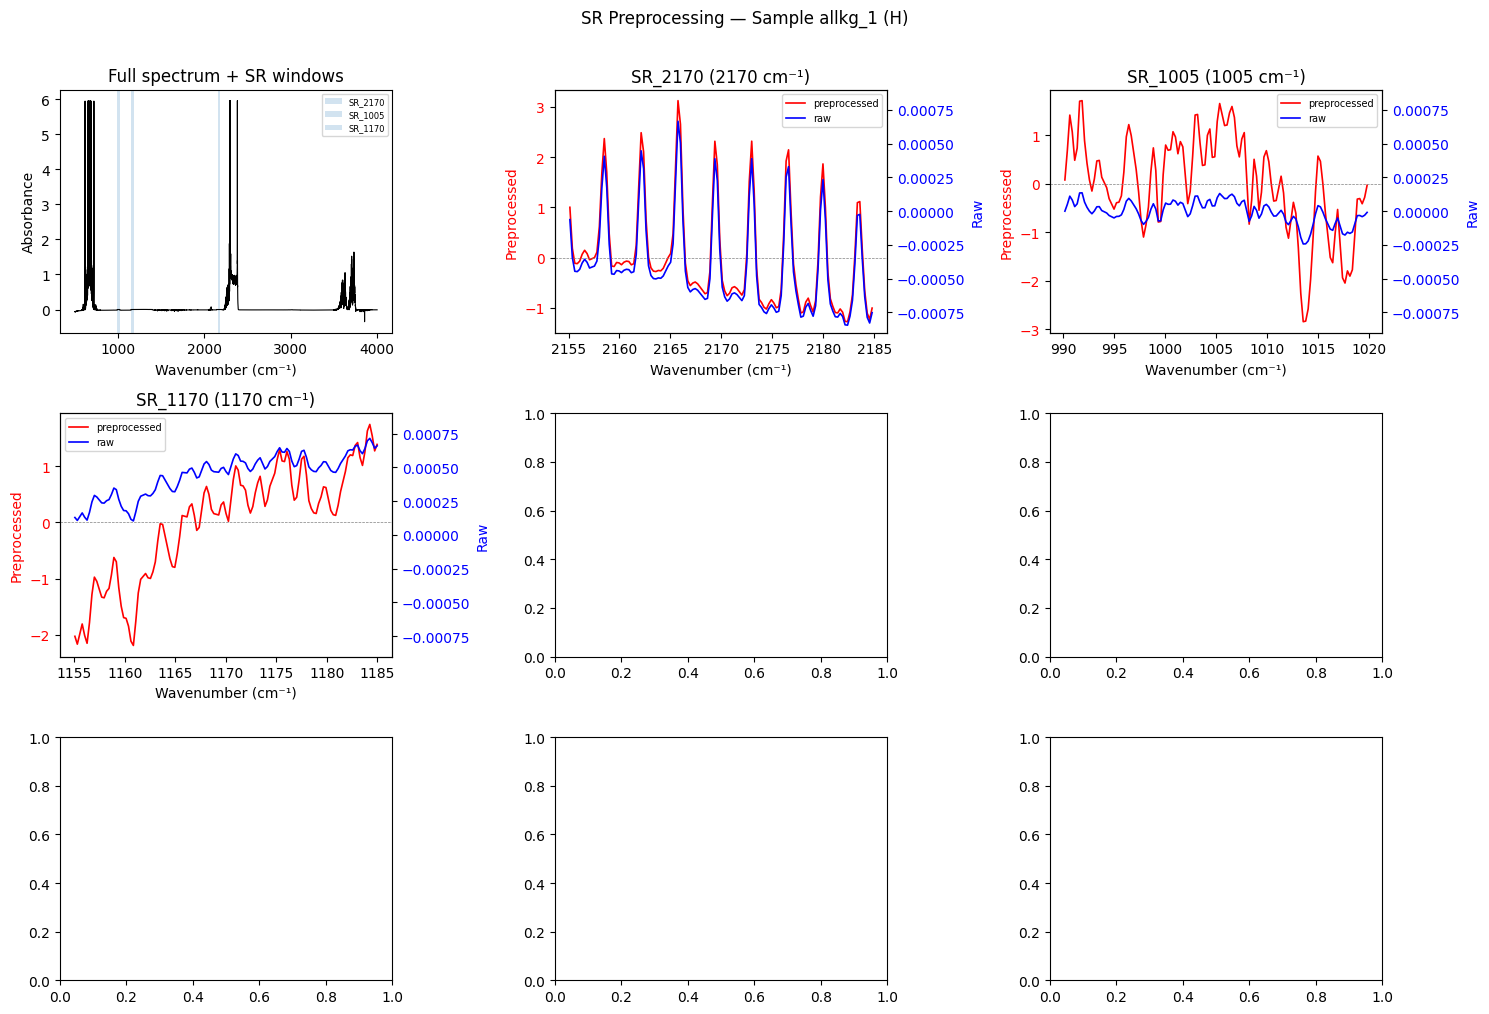

In [7]:
import matplotlib.pyplot as plt

# Pick one sample to visualize
i = 0
spectrum = np.array(df["intensity_baseline_corrected"].iloc[i])
wavenumbers = np.array(df["wavenumber"].iloc[i])
new_dict = {k:all_sr_results[i][k] for k in ['SR_2170', 'SR_1005', 'SR_1170']}

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot full spectrum in first panel with SR windows marked
ax = axes[0]
ax.plot(wavenumbers, spectrum, 'k', lw=0.8)
for sr_name, res in new_dict.items():
    ax.axvspan(res['center'] - 15, res['center'] + 15, alpha=0.2, label=sr_name)
ax.set_title("Full spectrum + SR windows")
ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("Absorbance")
ax.legend(fontsize=6)

# Plot each SR window (raw vs preprocessed)
for idx, (sr_name, res) in enumerate(new_dict.items()):
    ax = axes[idx + 1]
    wn = res['wavenumbers']

    # Raw window (before preprocessing)
    from sr_preprocessing import extract_sr_window
    raw, _ = extract_sr_window(spectrum, wavenumbers, res['center'])

    # Red preprocessed on left axis
    ax.plot(wn, res['spectrum'], 'r', label='preprocessed', lw=1.2)
    ax.set_ylabel("Preprocessed", color='r')
    ax.tick_params(axis='y', labelcolor='r')
    ax.axhline(0, color='gray', lw=0.5, ls='--')

    # Blue raw on right axis
    ax2 = ax.twinx()
    ax2.plot(wn, raw, 'b', label='raw', lw=1.2)
    ax2.set_ylim(-0.0009, 0.0009)
    ax2.set_ylabel("Raw", color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    ax.set_title(f"{sr_name} ({res['center']} cm⁻¹)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.suptitle(f"SR Preprocessing — Sample {df['patient_id'].iloc[i]} ({df['infoP'].iloc[i]})", y=1.01)
plt.tight_layout()
plt.show()


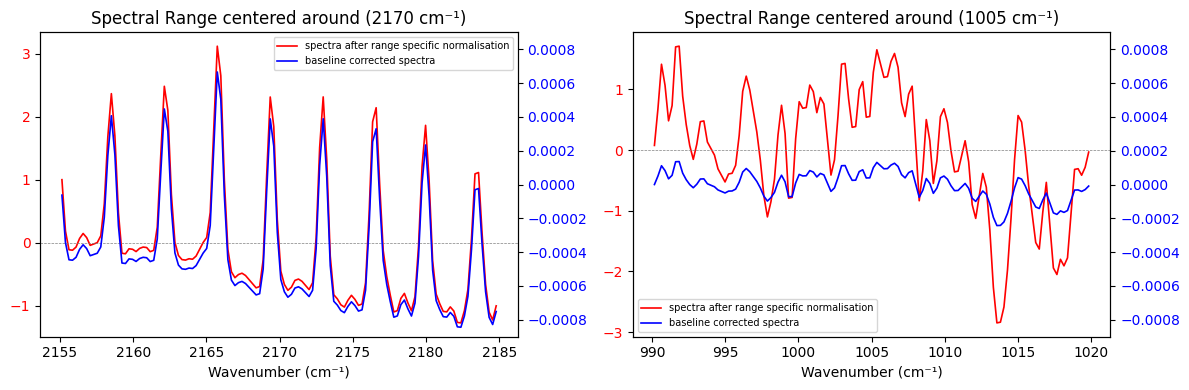

In [8]:
# Pick one sample to visualize
i = 0
spectrum = np.array(df["intensity_baseline_corrected"].iloc[i])
wavenumbers = np.array(df["wavenumber"].iloc[i])
new_dict = {k:all_sr_results[i][k] for k in ['SR_2170', 'SR_1005']}

n_plots = len(new_dict)
ncols = 2
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

# # Plot full spectrum in first panel with SR windows marked
# ax = axes[0]
# ax.plot(wavenumbers, spectrum, 'k', lw=0.8)
# for sr_name, res in new_dict.items():
#     ax.axvspan(res['center'] - 15, res['center'] + 15, alpha=0.2, label=sr_name)
# ax.set_title("Full spectrum + SR windows")
# ax.set_xlabel("Wavenumber (cm⁻¹)")
# ax.set_ylabel("Absorbance")
# ax.legend(fontsize=6)

# Plot each SR window (raw vs preprocessed)
for idx, (sr_name, res) in enumerate(new_dict.items()):
    ax = axes[idx]
    wn = res['wavenumbers']

    from sr_preprocessing import extract_sr_window
    raw, _ = extract_sr_window(spectrum, wavenumbers, res['center'])

    ax.plot(wn, res['spectrum'], 'r', label='spectra after range specific normalisation', lw=1.2)
    # ax.set_ylabel("Preprocessed", color='r')
    ax.tick_params(axis='y', labelcolor='r')
    ax.axhline(0, color='gray', lw=0.5, ls='--')

    ax2 = ax.twinx()
    ax2.plot(wn, raw, 'b', label='baseline corrected spectra', lw=1.2)
    ax2.set_ylim(-0.0009, 0.0009)
    # ax2.set_ylabel("Raw", color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    ax.set_title(f"Spectral Range centered around ({res['center']} cm⁻¹)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

# Hide any unused axes
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

# plt.suptitle(f"SR Preprocessing — Sample {df['patient_id'].iloc[i]} ({df['infoP'].iloc[i]})", y=1.01)
plt.tight_layout()
plt.show()

Compare with whole spectra normalization instead of spectral region specific

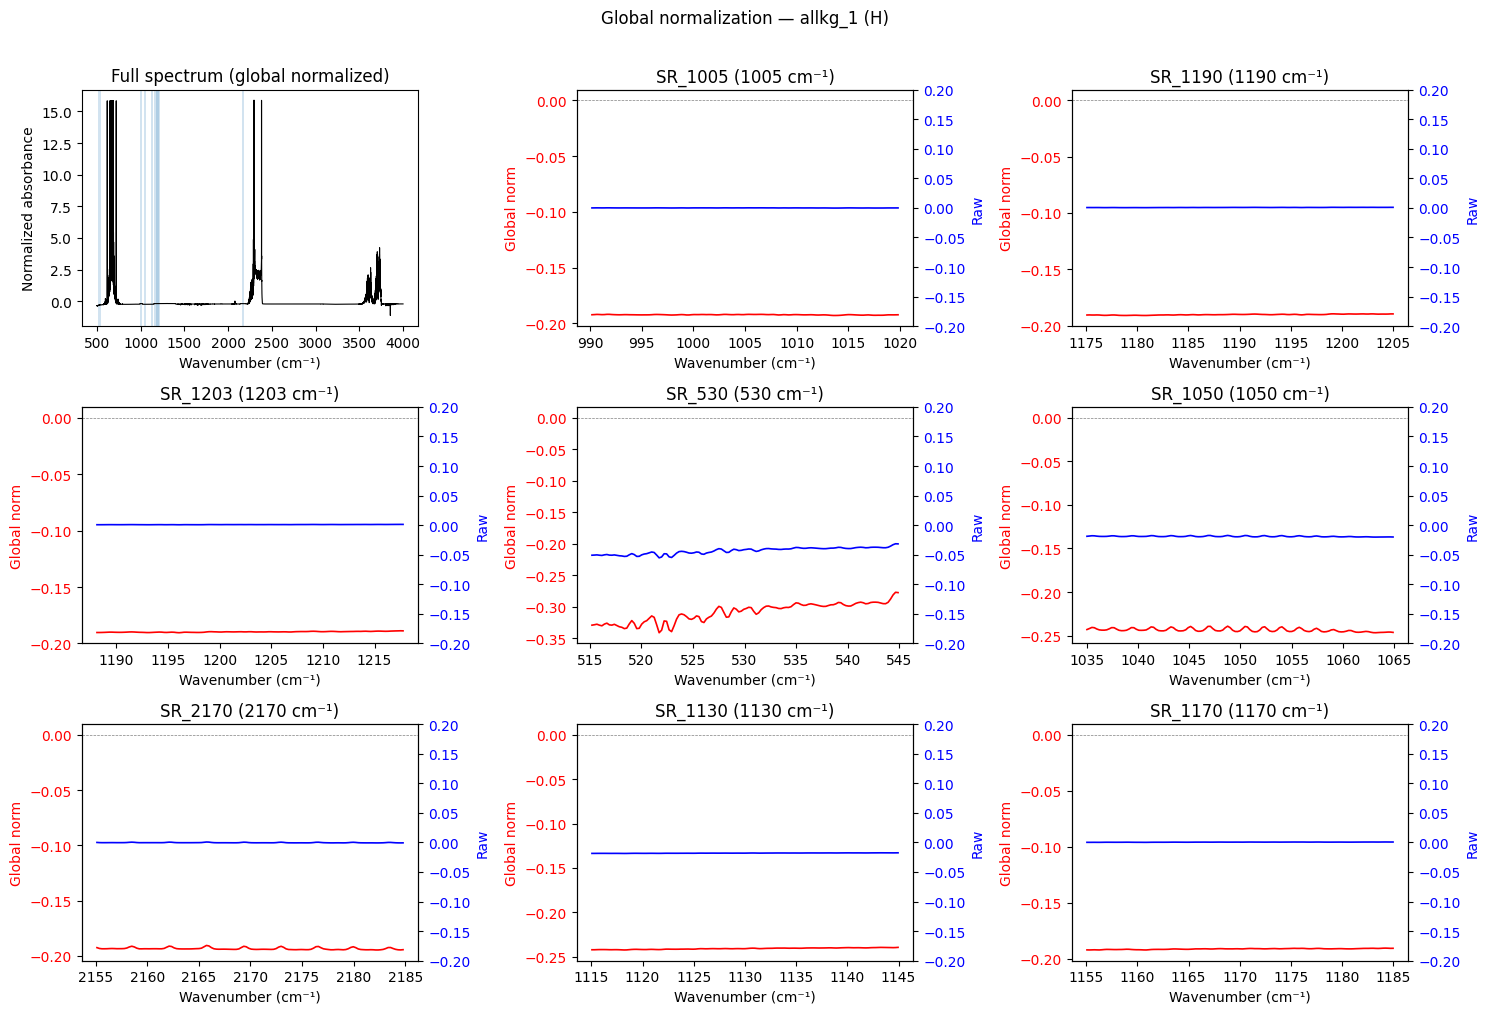

In [9]:
import matplotlib.pyplot as plt
from sr_preprocessing import extract_sr_window, SR_CENTERS

# Patient allkg_1
i = 0
wn = np.array(df["wavenumber"].iloc[i])
spec = np.array(df["intensity_baseline_corrected"].iloc[i])

# Normalize entire spectrum
spec_norm = (spec - spec.mean()) / spec.std()

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

# Full spectrum
axes[0].plot(wn, spec_norm, 'k', lw=0.8)
for name, center in SR_CENTERS.items():
    axes[0].axvspan(center - 15, center + 15, alpha=0.2)
axes[0].set_title("Full spectrum (global normalized)")
axes[0].set_xlabel("Wavenumber (cm⁻¹)")
axes[0].set_ylabel("Normalized absorbance")

# SR windows
for idx, (name, center) in enumerate(SR_CENTERS.items()):
    ax = axes[idx + 1]
    raw_win, win_wn = extract_sr_window(spec, wn, center)
    norm_win, _ = extract_sr_window(spec_norm, wn, center)

    ax.plot(win_wn, norm_win, 'r', lw=1.2, label='global norm')
    ax.set_ylabel("Global norm", color='r')
    ax.tick_params(axis='y', labelcolor='r')

    ax2 = ax.twinx()
    ax2.plot(win_wn, raw_win, 'b', lw=1.2, label='raw')
    ax2.set_ylim(-0.2, 0.2)
    ax2.set_ylabel("Raw", color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    ax.set_title(f"{name} ({center} cm⁻¹)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.axhline(0, color='gray', lw=0.5, ls='--')

plt.suptitle(f"Global normalization — {df['patient_id'].iloc[i]} ({df['infoP'].iloc[i]})", y=1.01)
plt.tight_layout()
plt.show()

### Test grid_Search.py

In [10]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   patient_id                    47 non-null     object
 1   original_filename             47 non-null     object
 2   category                      47 non-null     object
 3   normVP                        47 non-null     int64 
 4   infoP                         47 non-null     object
 5   wavenumber                    47 non-null     object
 6   intensity                     47 non-null     object
 7   spectrum_length               47 non-null     int64 
 8   intensity_baseline_corrected  47 non-null     object
 9   SR_1005_preprocessed          47 non-null     object
 10  SR_1190_preprocessed          47 non-null     object
 11  SR_1203_preprocessed          47 non-null     object
 12  SR_530_preprocessed           47 non-null     object
 13  SR_1050_preprocessed  

In [11]:
from grid_search import SVMHyperparameterSearchFixed

df_train = df_new   

# X is a 2D numpy array of shape (n_samples, n_features) where each row is one patient's feature vector.                                                                                                                                                                                                                                                                                                      
# Each row is built by concatenating the 8 preprocessed SR windows end-to-end:                                                                                                                                                                                                                                                                                                                                                  
# [SR_1005 (30pts) | SR_1190 (30pts) | SR_1203 (30pts) | ... | SR_1170 (30pts)] ~ 332 points in each SR
X = np.array([  
    np.concatenate([df_train[f'{sr}_preprocessed'].iloc[i] for sr in sr_names])                                                                                                                                
    for i in range(len(df_train))                                                                                                                                                                              
])
                                                                                                                                                                                                                
y = df_train['infoP'].values
print(f"X shape: {X.shape}")
print(f"Classes: {dict(zip(*np.unique(y, return_counts=True)))}")
                                                                                                                                                                                                                 


X shape: (47, 996)
Classes: {'BC': np.int64(5), 'H': np.int64(22), 'KC': np.int64(3), 'PC': np.int64(17)}


In [12]:
y

array(['H', 'PC', 'PC', 'H', 'PC', 'BC', 'PC', 'PC', 'BC', 'BC', 'PC',
       'PC', 'PC', 'PC', 'H', 'H', 'PC', 'PC', 'KC', 'PC', 'KC', 'PC',
       'BC', 'BC', 'PC', 'KC', 'PC', 'PC', 'PC', 'H', 'H', 'H', 'H', 'H',
       'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H'],
      dtype=object)

In [13]:
# --- Binary comparisons ---
comparisons = {
    'H_vs_PC':    ['H', 'PC'],
    'H_vs_KC':    ['H', 'KC'],
    'H_vs_BC':    ['H', 'BC'],
    'H_vs_KC_BC': ['H', 'KC', 'BC'],
}

grid_results = {}

for name, classes in comparisons.items():
    mask = np.isin(y, classes)
    X_sub = X[mask]
    y_sub = y[mask]
    print(f"\n{'='*60}")
    print(f"Comparison: {name}  |  n={len(y_sub)}  |  classes={dict(zip(*np.unique(y_sub, return_counts=True)))}")

    searcher = SVMHyperparameterSearchFixed(feature_type='whole_sr', use_nested_cv=True)
    
    # Reduce grid for speed — swap to full grid when ready
    searcher.param_grid['gaussian_sigma'] = [0, 5, 10, 20]
    searcher.param_grid['C'] = [0.1, 1.0, 10.0]
    searcher.param_grid['kernel'] = ['rbf']

    best = searcher.search(X_sub, y_sub, cv_folds=5, verbose=1)
    grid_results[name] = {'searcher': searcher, 'best': best}



Comparison: H_vs_PC  |  n=39  |  classes={'H': np.int64(22), 'PC': np.int64(17)}

NESTED CV - Feature Type: whole_sr
Data shape: (39, 996)
Outer CV folds: 5
Inner CV folds: 5

Outer fold 1/5:
  Train: 31, Test: 8


  Inner best: 0.8429
  Outer test: 0.5000

Outer fold 2/5:
  Train: 31, Test: 8
  Inner best: 0.7524
  Outer test: 0.5000

Outer fold 3/5:
  Train: 31, Test: 8
  Inner best: 0.8714
  Outer test: 0.7500

Outer fold 4/5:
  Train: 31, Test: 8
  Inner best: 0.8429
  Outer test: 0.6250

Outer fold 5/5:
  Train: 32, Test: 7
  Inner best: 0.7619
  Outer test: 0.8571

NESTED CV Results:
  Mean accuracy: 0.6464 ± 0.1403
  Fold scores: ['0.500', '0.500', '0.750', '0.625', '0.857']

  Final params (majority vote across 5 folds):
  kernel=rbf, C=10.0, sigma=0
  NOTE: nested CV accuracy (0.6464) is your reportable estimate. Re-run simple grid search on full data to confirm final params.


Comparison: H_vs_KC  |  n=25  |  classes={'H': np.int64(22), 'KC': np.int64(3)}

NESTED CV - Feature Type: whole_sr
Data shape: (25, 996)
Outer CV folds: 5
Inner CV folds: 5

Outer fold 1/5:
  Train: 20, Test: 5


/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selecti

  Inner best: 0.9000
  Outer test: 0.0000

Outer fold 2/5:
  Train: 20, Test: 5


/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selecti

...

/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selecti

  Inner best: 0.7600
  Outer test: 0.6667

Outer fold 5/5:
  Train: 24, Test: 6


/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selecti

  Inner best: 0.6300
  Outer test: 0.8333

NESTED CV Results:
  Mean accuracy: 0.6667 ± 0.1054
  Fold scores: ['0.667', '0.500', '0.667', '0.667', '0.833']

  Final params (majority vote across 5 folds):
  kernel=rbf, C=10.0, sigma=0
  NOTE: nested CV accuracy (0.6667) is your reportable estimate. Re-run simple grid search on full data to confirm final params.



/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [14]:
import pandas as pd

# Summary table of best configs per comparison
rows = []
for name, res in grid_results.items():
    b = res['best']
    rows.append({
        'comparison': name,
        'best_accuracy': f"{b['mean_accuracy']:.4f} ± {b['std_accuracy']:.4f}",
        'kernel': b['kernel'],
        'C': b['C'],
        'sigma': b['sigma'],
        'gamma': b['gamma'],
    })

pd.DataFrame(rows)


,comparison,best_accuracy,kernel,C,sigma,gamma
0,H_vs_PC,0.8429 ± 0.1393,rbf,10.0,0,scale
1,H_vs_KC,0.9000 ± 0.1225,rbf,10.0,0,scale
2,H_vs_BC,0.7100 ± 0.1068,rbf,10.0,0,scale
3,H_vs_KC_BC,0.5900 ± 0.1114,rbf,10.0,0,scale


### Systematic Hyperparameter Search — All Configurations
Define all model configs upfront, run grid search for each, store results in one DataFrame.

In [15]:
import itertools
import pandas as pd
import numpy as np

# ── Define all configurations ─────────────────────────────────────────────
# Each row = one (feature_type, sr_mode, sr_col, n_pca_components, task) combo

                                                                                                                                                                           
                                                                                                                                                                                                                 
GRIDS = {                                                                                                                                                                                                      
    'fast': {                                                                                                                                                                                                
        'gaussian_sigma': [0, 10, 20],                                                                                                                                                                         
        'kernel': ['rbf', 'linear'],                                                                                                                                                                           
        'C': [0.1, 1.0, 10.0],                                                                                                                                                                                 
        'gamma': ['scale', 'auto'],                                                                                                                                                                            
        'degree': [3],
    },                                                                                                                                                                                                         
    'medium': {                                                                                                                                                                                                
        'gaussian_sigma': [0, 5, 10, 15, 20],
        'kernel': ['rbf'],                                                                                                                                                                           
        'C': [0.01, 0.2575, 0.505, 0.7525, 1.0],
        'gamma': ['scale', 'auto'],                                                                                                                                                                            
        'degree': [3],
    },                                                                                                                                                                                                         
    'slow': {   
        'gaussian_sigma': [0, 1, 2, 3, 5, 10, 15, 20, 25],                                                                                                                                                     
        'kernel': ['rbf', 'linear', 'poly'],
        'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],                                                                                                                                                     
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4],                                                                                                                                                                                   
    }           
}                                                                                                                                                                                                              
                  

SR_COLUMNS = [
    'SR_1005_preprocessed', 'SR_1190_preprocessed', 'SR_1203_preprocessed',
    'SR_530_preprocessed',  'SR_1050_preprocessed', 'SR_2170_preprocessed',
    'SR_1130_preprocessed', 'SR_1170_preprocessed'
]

TASKS = [
    ('H_vs_PC',      'H', 'PC'),
    # ('H_vs_KC',      'H', 'KC'),
    # ('H_vs_BC',      'H', 'BC'),
    # ('H_vs_KC_BC',   'H', ['KC', 'BC']),
    ('H_vs_KC_BC_PC', 'H', ['KC', 'BC', 'PC'])
]

rows = []

for task_name, c0, c1 in TASKS:
    # --- (A) Single SR, whole spectrum ---
    for sr_col in SR_COLUMNS:
        rows.append({
            'config_id':        f'single_whole__{sr_col}__{task_name}',
            'feature_type':     'whole_sr',
            'sr_mode':          'single',
            'sr_col':           sr_col,
            'n_pca_components': None,
            'task':             task_name,
            'c0': c0, 'c1': c1,
        })

    # --- (B) Single SR, PCA top 4 ---
    for sr_col in SR_COLUMNS:
        rows.append({
            'config_id':        f'single_pca4__{sr_col}__{task_name}',
            'feature_type':     'pca',
            'sr_mode':          'single',
            'sr_col':           sr_col,
            'n_pca_components': 4,
            'task':             task_name,
            'c0': c0, 'c1': c1,
        })

    # --- (C) All SRs concatenated, whole spectrum ---
    rows.append({
        'config_id':        f'concat_whole__all_sr__{task_name}',
        'feature_type':     'whole_sr',
        'sr_mode':          'concat',
        'sr_col':           'all',
        'n_pca_components': None,
        'task':             task_name,
        'c0': c0, 'c1': c1,
    })

    # --- (D) All SRs concatenated, PCA top 4 ---
    rows.append({
        'config_id':        f'concat_pca4__all_sr__{task_name}',
        'feature_type':     'pca',
        'sr_mode':          'concat',
        'sr_col':           'all',
        'n_pca_components': 4,
        'task':             task_name,
        'c0': c0, 'c1': c1,
    })

# Add empty result columns — filled in by the search loop below
result_cols = ['best_sigma', 'best_kernel', 'best_C', 'best_gamma',
               'best_degree', 'cv_accuracy', 'cv_std', 'n_samples', 'status']
for col in result_cols:
    for row in rows:
        row[col] = None

configs = pd.DataFrame(rows)
print(f"Total configs: {len(configs)}")
print(f"  single_whole : {len(configs[configs.feature_type=='whole_sr'][configs.sr_mode=='single'])}")
print(f"  single_pca4  : {len(configs[configs.feature_type=='pca'][configs.sr_mode=='single'])}")
print(f"  concat_whole : {len(configs[(configs.feature_type=='whole_sr') & (configs.sr_mode=='concat')])}")
print(f"  concat_pca4  : {len(configs[(configs.feature_type=='pca') & (configs.sr_mode=='concat')])}")
configs[['config_id','feature_type','sr_mode','sr_col','n_pca_components','task']].head(20)

Total configs: 36
  single_whole : 16
  single_pca4  : 16
  concat_whole : 2
  concat_pca4  : 2


/tmp/ipykernel_85714/1830363378.py:107: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"  single_whole : {len(configs[configs.feature_type=='whole_sr'][configs.sr_mode=='single'])}")
/tmp/ipykernel_85714/1830363378.py:108: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"  single_pca4  : {len(configs[configs.feature_type=='pca'][configs.sr_mode=='single'])}")


,config_id,feature_type,sr_mode,sr_col,n_pca_components,task
0,single_whole__SR_1005_preprocessed__H_vs_PC,whole_sr,single,SR_1005_preprocessed,NaN,H_vs_PC
1,single_whole__SR_1190_preprocessed__H_vs_PC,whole_sr,single,SR_1190_preprocessed,NaN,H_vs_PC
2,single_whole__SR_1203_preprocessed__H_vs_PC,whole_sr,single,SR_1203_preprocessed,NaN,H_vs_PC
3,single_whole__SR_530_preprocessed__H_vs_PC,whole_sr,single,SR_530_preprocessed,NaN,H_vs_PC
4,single_whole__SR_1050_preprocessed__H_vs_PC,whole_sr,single,SR_1050_preprocessed,NaN,H_vs_PC
5,single_whole__SR_2170_preprocessed__H_vs_PC,whole_sr,single,SR_2170_preprocessed,NaN,H_vs_PC
6,single_whole__SR_1130_preprocessed__H_vs_PC,whole_sr,single,SR_1130_preprocessed,NaN,H_vs_PC
7,single_whole__SR_1170_preprocessed__H_vs_PC,whole_sr,single,SR_1170_preprocessed,NaN,H_vs_PC
8,single_pca4__SR_1005_preprocessed__H_vs_PC,pca,single,SR_1005_preprocessed,4.0,H_vs_PC
9,single_pca4__SR_1190_preprocessed__H_vs_PC,pca,single,SR_1190_preprocessed,4.0,H_vs_PC


In [16]:
configs.head()

,config_id,feature_type,sr_mode,sr_col,n_pca_components,task,c0,c1,best_sigma,best_kernel,best_C,best_gamma,best_degree,cv_accuracy,cv_std,n_samples,status
0,single_whole__SR_1005_preprocessed__H_vs_PC,whole_sr,single,SR_1005_preprocessed,NaN,H_vs_PC,H,PC,None,None,None,None,None,None,None,None,None
1,single_whole__SR_1190_preprocessed__H_vs_PC,whole_sr,single,SR_1190_preprocessed,NaN,H_vs_PC,H,PC,None,None,None,None,None,None,None,None,None
2,single_whole__SR_1203_preprocessed__H_vs_PC,whole_sr,single,SR_1203_preprocessed,NaN,H_vs_PC,H,PC,None,None,None,None,None,None,None,None,None
3,single_whole__SR_530_preprocessed__H_vs_PC,whole_sr,single,SR_530_preprocessed,NaN,H_vs_PC,H,PC,None,None,None,None,None,None,None,None,None
4,single_whole__SR_1050_preprocessed__H_vs_PC,whole_sr,single,SR_1050_preprocessed,NaN,H_vs_PC,H,PC,None,None,None,None,None,None,None,None,None


In [17]:
# ── Run hyperparameter search for all configs ──────────────────────────────
# Set GRID to 'fast' for a quick test, 'medium' for exploration, 'slow' for final.

import importlib, grid_search
importlib.reload(grid_search)
from grid_search import SVMHyperparameterSearchFixed
GRID = 'medium'   # change to 'fast' / 'slow'
CV_FOLDS = 9

for idx, row in configs.iterrows():
    task_name = row['task']
    c0, c1 = row['c0'], row['c1']
    classes  = [c0] + (c1 if isinstance(c1, list) else [c1])

    # Filter data for this task
    mask   = np.isin(df_new['infoP'], classes)
    df_sub = df_new[mask].reset_index(drop=True)
    y_sub  = df_sub['infoP'].values
    # Collapse cancer subtypes to 'cancer' for multi-cancer tasks (e.g. H_vs_KC_BC_PC)
    # Makes stratification and SVM binary end-to-end — no post-hoc collapsing needed
    if len(classes) > 2:
        y_sub = np.where(y_sub == 'H', 'H', 'cancer')
    n      = len(y_sub)

    # Build feature matrix
    if row['sr_mode'] == 'single':
        X_sub = np.array(list(df_sub[row['sr_col']]))
    else:  # concat
        X_sub = np.hstack([np.array(list(df_sub[col])) for col in SR_COLUMNS])

    n_pca = row['n_pca_components']
    feat  = row['feature_type']

    # Clamp CV_FOLDS to the size of the smallest class
    min_class_count = min(np.bincount(np.unique(y_sub, return_inverse=True)[1]))
    safe_folds = min(CV_FOLDS, min_class_count)
    if safe_folds < CV_FOLDS:
        print(f"  ⚠ Clamped folds {CV_FOLDS}→{safe_folds} (min class n={min_class_count})")

    print(f"[{idx+1}/{len(configs)}] {row['config_id']}  "
          f"(n={n}, X={X_sub.shape[1]}, folds={safe_folds})")

    try:
        searcher = SVMHyperparameterSearchFixed(
            feature_type=feat,
            n_pca_components=int(n_pca) if pd.notna(n_pca) else 4,
            use_nested_cv=False
        )
        searcher.param_grid = GRIDS[GRID]
        searcher.search(X_sub, y_sub, cv_folds=safe_folds, verbose=0)

        bp = searcher.best_params_
        configs.at[idx, 'best_sigma']  = bp['sigma']
        configs.at[idx, 'best_kernel'] = bp['kernel']
        configs.at[idx, 'best_C']      = bp['C']
        configs.at[idx, 'best_gamma']  = bp['gamma']
        configs.at[idx, 'best_degree'] = bp['degree']
        configs.at[idx, 'cv_accuracy'] = round(searcher.best_score_, 4)
        configs.at[idx, 'cv_std']      = round(bp['std_accuracy'], 4)
        configs.at[idx, 'n_samples']   = n
        configs.at[idx, 'status']      = 'done'

    except Exception as e:
        configs.at[idx, 'status'] = f'ERROR: {e}'
        print(f"  ERROR: {e}")

# Save
configs.to_csv('eval_result_data/all_configs_best_params.csv', index=False)
print("\nDone. Saved to eval_result_data/all_configs_best_params.csv")

[1/36] single_whole__SR_1005_preprocessed__H_vs_PC  (n=39, X=124, folds=9)
[2/36] single_whole__SR_1190_preprocessed__H_vs_PC  (n=39, X=125, folds=9)
[3/36] single_whole__SR_1203_preprocessed__H_vs_PC  (n=39, X=124, folds=9)
[4/36] single_whole__SR_530_preprocessed__H_vs_PC  (n=39, X=124, folds=9)
[5/36] single_whole__SR_1050_preprocessed__H_vs_PC  (n=39, X=125, folds=9)
[6/36] single_whole__SR_2170_preprocessed__H_vs_PC  (n=39, X=124, folds=9)
[7/36] single_whole__SR_1130_preprocessed__H_vs_PC  (n=39, X=125, folds=9)
[8/36] single_whole__SR_1170_preprocessed__H_vs_PC  (n=39, X=125, folds=9)
[9/36] single_pca4__SR_1005_preprocessed__H_vs_PC  (n=39, X=124, folds=9)
[10/36] single_pca4__SR_1190_preprocessed__H_vs_PC  (n=39, X=125, folds=9)
[11/36] single_pca4__SR_1203_preprocessed__H_vs_PC  (n=39, X=124, folds=9)
[12/36] single_pca4__SR_530_preprocessed__H_vs_PC  (n=39, X=124, folds=9)
[13/36] single_pca4__SR_1050_preprocessed__H_vs_PC  (n=39, X=125, folds=9)
[14/36] single_pca4__SR_2170

In [18]:
# ── Inspect results ────────────────────────────────────────────────────────
show_cols = ['config_id', 'task', 'n_samples', 'cv_accuracy', 'cv_std',
             'best_sigma', 'best_kernel', 'best_C', 'status']

# All results sorted by accuracy
# configs[show_cols].sort_values('cv_accuracy', ascending=False).head(40)
configs[show_cols][~configs["task"].isin(["H_vs_BC", "H_vs_KC"])].sort_values('cv_accuracy', ascending=False).head(40)                                                                                         

,config_id,task,n_samples,cv_accuracy,cv_std,best_sigma,best_kernel,best_C,status
8,single_pca4__SR_1005_preprocessed__H_vs_PC,H_vs_PC,39,0.8722,0.1652,15,rbf,0.7525,done
26,single_pca4__SR_1005_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.8519,0.1238,15,rbf,0.2575,done
17,concat_pca4__all_sr__H_vs_PC,H_vs_PC,39,0.85,0.1856,5,rbf,0.7525,done
33,single_pca4__SR_1170_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.8296,0.1914,0,rbf,0.505,done
18,single_whole__SR_1005_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.8111,0.0801,0,rbf,0.2575,done
15,single_pca4__SR_1170_preprocessed__H_vs_PC,H_vs_PC,39,0.8056,0.202,0,rbf,1.0,done
27,single_pca4__SR_1190_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.7704,0.1895,0,rbf,0.2575,done
29,single_pca4__SR_530_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.7667,0.1886,0,rbf,0.2575,done
28,single_pca4__SR_1203_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.7667,0.1886,20,rbf,0.2575,done
25,single_whole__SR_1170_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.7667,0.1886,0,rbf,0.2575,done


In [19]:
# ── Filter: only high-performing configs ──────────────────────────────────
configs[
    (configs['status'] == 'done') &
    (configs['cv_accuracy'] >= 0.80)
][show_cols].sort_values('cv_accuracy', ascending=False)

,config_id,task,n_samples,cv_accuracy,cv_std,best_sigma,best_kernel,best_C,status
8,single_pca4__SR_1005_preprocessed__H_vs_PC,H_vs_PC,39,0.8722,0.1652,15,rbf,0.7525,done
26,single_pca4__SR_1005_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.8519,0.1238,15,rbf,0.2575,done
17,concat_pca4__all_sr__H_vs_PC,H_vs_PC,39,0.85,0.1856,5,rbf,0.7525,done
33,single_pca4__SR_1170_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.8296,0.1914,0,rbf,0.505,done
18,single_whole__SR_1005_preprocessed__H_vs_KC_BC_PC,H_vs_KC_BC_PC,47,0.8111,0.0801,0,rbf,0.2575,done
15,single_pca4__SR_1170_preprocessed__H_vs_PC,H_vs_PC,39,0.8056,0.202,0,rbf,1.0,done


### Final SVM Evaluation — LOOCV + K-Fold for All Configs
Runs LOOCV and 9-fold (x10 repeats) on every config in the `configs` table.
Results stored in `results_df`. Blind set stored separately in `blind_df`.

In [20]:
# ── Step 1: Add readable subcolumns to configs ────────────────────────────
# sr_type : 'single' or 'concat'
# sr_used : SR column name, or 'all' if concatenated
# pca     : 1 if PCA was used, 0 if whole spectrum

import importlib, SVM_implement
importlib.reload(SVM_implement)
from SVM_implement import SVMBreathClassifier

configs['sr_type'] = configs['sr_mode']   # 'single' or 'concat'
configs['sr_used'] = configs['sr_col'].apply(
    lambda x: 'all' if x == 'all' else x.replace('_preprocessed', '')
)
configs['pca'] = (configs['feature_type'] == 'pca').astype(int)

# Preview the readable columns
configs[['config_id','sr_type','sr_used','pca','task','cv_accuracy','status']].head(20)

,config_id,sr_type,sr_used,pca,task,cv_accuracy,status
0,single_whole__SR_1005_preprocessed__H_vs_PC,single,SR_1005,0,H_vs_PC,0.7667,done
1,single_whole__SR_1190_preprocessed__H_vs_PC,single,SR_1190,0,H_vs_PC,0.7056,done
2,single_whole__SR_1203_preprocessed__H_vs_PC,single,SR_1203,0,H_vs_PC,0.7056,done
3,single_whole__SR_530_preprocessed__H_vs_PC,single,SR_530,0,H_vs_PC,0.7278,done
4,single_whole__SR_1050_preprocessed__H_vs_PC,single,SR_1050,0,H_vs_PC,0.75,done
5,single_whole__SR_2170_preprocessed__H_vs_PC,single,SR_2170,0,H_vs_PC,0.5056,done
6,single_whole__SR_1130_preprocessed__H_vs_PC,single,SR_1130,0,H_vs_PC,0.7,done
7,single_whole__SR_1170_preprocessed__H_vs_PC,single,SR_1170,0,H_vs_PC,0.7278,done
8,single_pca4__SR_1005_preprocessed__H_vs_PC,single,SR_1005,1,H_vs_PC,0.8722,done
9,single_pca4__SR_1190_preprocessed__H_vs_PC,single,SR_1190,1,H_vs_PC,0.7278,done


In [21]:
# ── Step 2: Run LOOCV + k-fold (k=7,9,11) for all completed configs ─────────
# This uses params already stored in configs / all_configs_best_params.csv.
# Results are stored in eval_rows — one row per (config, method).

from scipy.stats import beta as _beta_dist
from sklearn.metrics import matthews_corrcoef as _mcc

def clopper_pearson(k, n, alpha=0.05):
    lo = _beta_dist.ppf(alpha/2,   k,   n-k+1) if k > 0 else 0.0
    hi = _beta_dist.ppf(1-alpha/2, k+1, n-k)   if k < n else 1.0
    return round(float(lo), 4), round(float(hi), 4)

clf = SVMBreathClassifier()
eval_rows = []

K_VALUES = [7, 9, 11]   # k-fold values to evaluate

done_configs = configs[configs['status'] == 'done'].reset_index(drop=True)
print(f"Evaluating {len(done_configs)} configs...\n")

for _, cfg in done_configs.iterrows():
    task_name = cfg['task']
    c0 = cfg['c0']
    c1 = cfg['c1']
    classes = [c0] + (c1 if isinstance(c1, list) else [c1])

    # Filter data for this task
    mask   = np.isin(df_new['infoP'], classes)
    df_sub = df_new[mask].reset_index(drop=True)
    y_sub  = df_sub['infoP'].values
    # Collapse cancer subtypes to 'cancer' for multi-cancer tasks (e.g. H_vs_KC_BC_PC)
    # Makes stratification and SVM binary end-to-end — no post-hoc collapsing needed
    if len(classes) > 2:
        y_sub = np.where(y_sub == 'H', 'H', 'cancer')

    # Build feature matrix
    if cfg['sr_mode'] == 'single':
        X_sub = np.array(list(df_sub[cfg['sr_col']]))
    else:
        X_sub = np.hstack([np.array(list(df_sub[col])) for col in SR_COLUMNS])

    # Build params dict from configs row
    params = {
        'sigma':            cfg['best_sigma'],
        'kernel':           cfg['best_kernel'],
        'C':                cfg['best_C'],
        'gamma':            cfg['best_gamma'],
        'degree':           cfg['best_degree'] if cfg['best_kernel'] == 'poly' else None,
        'feature_type':     cfg['feature_type'],
        'n_pca_components': int(cfg['n_pca_components']) if pd.notna(cfg.get('n_pca_components')) else 4,
    }

    base_row = {
        'config_id': cfg['config_id'],
        'sr_type':   cfg['sr_type'],
        'sr_used':   cfg['sr_used'],
        'pca':       cfg['pca'],
        'task':      task_name,
        'n_samples': len(y_sub),
        'cv_accuracy': cfg['cv_accuracy'],   # grid search score (optimistic)
        **{k: v for k, v in params.items() if k not in ['feature_type','n_pca_components']},
    }

    # Clamp each k to the smallest class size
    min_class_count = min(np.bincount(np.unique(y_sub, return_inverse=True)[1]))
    safe_k_values = []
    for k in K_VALUES:
        sk = min(k, min_class_count)
        if sk < k:
            print(f"  ⚠ k={k} clamped to {sk} (min class n={min_class_count})")
        safe_k_values.append(sk)
    safe_k_values = sorted(set(safe_k_values))  # deduplicate if multiple k clamp to same value

    print(f"  {cfg['config_id']}")

    try:
        # LOOCV
        r = clf.loocv_validation(X_sub, y_sub, params)
        tp, tn, fn, fp = r['TP'], r['TN'], r['FN'], r['FP']
        mcc = _mcc(y_sub, r['y_pred'])
        sens_ci = clopper_pearson(tp, tp + fn)
        spec_ci = clopper_pearson(tn, tn + fp)
        eval_rows.append({**base_row, 'method': 'LOOCV',
                           'accuracy':          r['accuracy'],
                           'accuracy_std':      None,
                           'sensitivity':       r['sensitivity'],
                           'sensitivity_std':   None,
                           'specificity':       r['specificity'],
                           'specificity_std':   None,
                           'balanced_accuracy': (r['sensitivity'] + r['specificity']) / 2,
                           'mcc':               mcc,
                           'mcc_std':           None,
                           'sens_ci_lo':        sens_ci[0],
                           'sens_ci_hi':        sens_ci[1],
                           'spec_ci_lo':        spec_ci[0],
                           'spec_ci_hi':        spec_ci[1],
                           })

        # K-fold for each safe k
        for k in safe_k_values:
            rk = clf.kfold_validation(X_sub, y_sub, params, k=k, n_repeats=10)
            eval_rows.append({**base_row, 'method': f'{k}-fold (x10)',
                               'accuracy':          rk['accuracy'],
                               'accuracy_std':      rk['accuracy_std'],
                               'sensitivity':       rk['sensitivity'],
                               'sensitivity_std':   rk['sensitivity_std'],
                               'specificity':       rk['specificity'],
                               'specificity_std':   rk['specificity_std'],
                               'balanced_accuracy': rk['balanced_accuracy'],
                               'mcc':               rk['mcc'],
                               'mcc_std':           rk['mcc_std'],
                               'sens_ci_lo':        None,
                               'sens_ci_hi':        None,
                               'spec_ci_lo':        None,
                               'spec_ci_hi':        None,
                               })

    except Exception as e:
        print(f"    ERROR: {e}")

results_df = pd.DataFrame(eval_rows)
results_df.to_csv('eval_result_data/svm_evaluation_results.csv', index=False)
print(f"\nDone. {len(results_df)} rows saved to eval_result_data/svm_evaluation_results.csv")
print(f"Methods per config: LOOCV + {len(K_VALUES)} k-fold = {1 + len(K_VALUES)} rows each")

Evaluating 36 configs...

  single_whole__SR_1005_preprocessed__H_vs_PC
  single_whole__SR_1190_preprocessed__H_vs_PC
  single_whole__SR_1203_preprocessed__H_vs_PC
  single_whole__SR_530_preprocessed__H_vs_PC
  single_whole__SR_1050_preprocessed__H_vs_PC
  single_whole__SR_2170_preprocessed__H_vs_PC
  single_whole__SR_1130_preprocessed__H_vs_PC
  single_whole__SR_1170_preprocessed__H_vs_PC
  single_pca4__SR_1005_preprocessed__H_vs_PC
  single_pca4__SR_1190_preprocessed__H_vs_PC
  single_pca4__SR_1203_preprocessed__H_vs_PC
  single_pca4__SR_530_preprocessed__H_vs_PC
  single_pca4__SR_1050_preprocessed__H_vs_PC
  single_pca4__SR_2170_preprocessed__H_vs_PC
  single_pca4__SR_1130_preprocessed__H_vs_PC
  single_pca4__SR_1170_preprocessed__H_vs_PC
  concat_whole__all_sr__H_vs_PC
  concat_pca4__all_sr__H_vs_PC
  single_whole__SR_1005_preprocessed__H_vs_KC_BC_PC
  single_whole__SR_1190_preprocessed__H_vs_KC_BC_PC
  single_whole__SR_1203_preprocessed__H_vs_KC_BC_PC
  single_whole__SR_530_prepro

In [22]:
# ── Step 3: Inspect evaluation results ────────────────────────────────────
show = ['sr_type','sr_used','pca','task','method',
        'accuracy','sensitivity','specificity','accuracy_std','cv_accuracy']

# LOOCV results only, sorted by accuracy
loocv_results = results_df[results_df['method'] == 'LOOCV'][show].sort_values(
    'accuracy', ascending=False
).reset_index(drop=True)

# print(f"Top 20 configs by LOOCV accuracy:")
# loocv_results.head(20)

In [23]:
results_df

,config_id,sr_type,sr_used,pca,task,n_samples,cv_accuracy,sigma,kernel,C,...,sensitivity_std,specificity,specificity_std,balanced_accuracy,mcc,mcc_std,sens_ci_lo,sens_ci_hi,spec_ci_lo,spec_ci_hi
0,single_whole__SR_1005_preprocessed__H_vs_PC,single,SR_1005,0,H_vs_PC,39,0.7667,0,rbf,0.5050,...,NaN,0.818182,NaN,0.438503,-0.182431,NaN,0.0015,0.2869,0.5972,0.9481
1,single_whole__SR_1005_preprocessed__H_vs_PC,single,SR_1005,0,H_vs_PC,39,0.7667,0,rbf,0.5050,...,6.443795e-02,0.868182,0.051626,0.581150,0.201113,0.117504,NaN,NaN,NaN,NaN
2,single_whole__SR_1005_preprocessed__H_vs_PC,single,SR_1005,0,H_vs_PC,39,0.7667,0,rbf,0.5050,...,4.742505e-02,0.850000,0.035501,0.557353,0.142593,0.071470,NaN,NaN,NaN,NaN
3,single_whole__SR_1005_preprocessed__H_vs_PC,single,SR_1005,0,H_vs_PC,39,0.7667,0,rbf,0.5050,...,4.117647e-02,0.850000,0.020830,0.569118,0.167605,0.064489,NaN,NaN,NaN,NaN
4,single_whole__SR_1190_preprocessed__H_vs_PC,single,SR_1190,0,H_vs_PC,39,0.7056,0,rbf,0.7525,...,NaN,0.500000,NaN,0.485294,-0.029179,NaN,0.2298,0.7219,0.2822,0.7178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,concat_whole__all_sr__H_vs_KC_BC_PC,concat,all,0,H_vs_KC_BC_PC,47,0.7444,0,rbf,0.5050,...,2.220446e-16,0.500000,0.000000,0.730000,0.526398,0.000000,NaN,NaN,NaN,NaN
140,concat_pca4__all_sr__H_vs_KC_BC_PC,concat,all,1,H_vs_KC_BC_PC,47,0.7630,15,rbf,1.0000,...,NaN,0.590909,NaN,0.675455,0.356796,NaN,0.5487,0.9064,0.3635,0.7929
141,concat_pca4__all_sr__H_vs_KC_BC_PC,concat,all,1,H_vs_KC_BC_PC,47,0.7630,15,rbf,1.0000,...,5.306600e-02,0.645455,0.056773,0.718727,0.444490,0.088764,NaN,NaN,NaN,NaN
142,concat_pca4__all_sr__H_vs_KC_BC_PC,concat,all,1,H_vs_KC_BC_PC,47,0.7630,15,rbf,1.0000,...,2.561250e-02,0.613636,0.030492,0.712818,0.436437,0.038121,NaN,NaN,NaN,NaN


In [24]:
# ── Step 4: Filter — high sensitivity AND specificity ─────────────────────
results_df[
    (results_df['task'].isin(['H_vs_KC_BC_PC', 'H_vs_PC'])) &
    # (results_df['task'] == 'H_PC') &
    (results_df['sensitivity'] >= 0.70) &
    (results_df['specificity'] >= 0.70)
][show].sort_values(by=['accuracy'], ascending=False).head(30)

,sr_type,sr_used,pca,task,method,accuracy,sensitivity,specificity,accuracy_std,cv_accuracy
32,single,SR_1005,1,H_vs_PC,LOOCV,0.897436,0.882353,0.909091,NaN,0.8722
35,single,SR_1005,1,H_vs_PC,11-fold (x10),0.882051,0.858824,0.900000,0.020513,0.8722
34,single,SR_1005,1,H_vs_PC,9-fold (x10),0.879487,0.852941,0.900000,0.038118,0.8722
33,single,SR_1005,1,H_vs_PC,7-fold (x10),0.874359,0.841176,0.900000,0.033333,0.8722
68,concat,all,1,H_vs_PC,LOOCV,0.846154,0.705882,0.954545,NaN,0.8500


In [25]:
# ── Step 5: Blind set evaluation (Table 2 in Maiti 2021) ──────────────────
# Train on ALL df_new, test on df_blind (23 held-out patients).
# Run only for your best configs — not all 72.

# Pick top configs to evaluate on blind set
top_configs = results_df[
    (results_df['method'] == 'LOOCV') &
    (results_df['sensitivity'] >= 0.70) &
    (results_df['specificity'] >= 0.70)
].sort_values('accuracy', ascending=False).head(10)

blind_rows = []

for _, cfg_row in top_configs.iterrows():
    task_name = cfg_row['task']
    config_id = cfg_row['config_id']

    # Get full config from configs table
    cfg = configs[configs['config_id'] == config_id].iloc[0]
    c0, c1 = cfg['c0'], cfg['c1']
    classes = [c0] + (c1 if isinstance(c1, list) else [c1])

    # Training data: all of df_new filtered to task classes
    mask_train = np.isin(df_new['infoP'], classes)
    df_train   = df_new[mask_train].reset_index(drop=True)
    y_train    = df_train['infoP'].values

    # Blind set: df_blind filtered to task classes
    mask_blind = np.isin(df_blind['infoP'], classes)
    df_bl      = df_blind[mask_blind].reset_index(drop=True)
    y_blind    = df_bl['infoP'].values

    # Collapse cancer subtypes for multi-cancer tasks — keeps SVM binary end-to-end
    if len(classes) > 2:
        y_train = np.where(y_train == 'H', 'H', 'cancer')
        y_blind = np.where(y_blind == 'H', 'H', 'cancer')

    if len(y_blind) == 0:
        print(f"  SKIP {task_name}: no blind samples for classes {classes}")
        continue

    # Build feature matrices
    if cfg['sr_mode'] == 'single':
        X_train = np.array(list(df_train[cfg['sr_col']]))
        X_blind = np.array(list(df_bl[cfg['sr_col']]))
    else:
        X_train = np.hstack([np.array(list(df_train[col])) for col in SR_COLUMNS])
        X_blind = np.hstack([np.array(list(df_bl[col]))   for col in SR_COLUMNS])

    params = {
        'sigma':            cfg['best_sigma'],
        'kernel':           cfg['best_kernel'],
        'C':                cfg['best_C'],
        'gamma':            cfg['best_gamma'],
        'degree':           cfg['best_degree'] if cfg['best_kernel'] == 'poly' else None,
        'feature_type':     cfg['feature_type'],
        'n_pca_components': int(cfg['n_pca_components']) if pd.notna(cfg.get('n_pca_components')) else 4,
    }

    print(f"  Blind: {config_id} | n_train={len(y_train)}, n_blind={len(y_blind)}")

    try:
        r = clf.blind_set_evaluation(X_train, y_train, X_blind, y_blind, params)
        blind_rows.append({
            'config_id':   config_id,
            'sr_type':     cfg['sr_type'],
            'sr_used':     cfg['sr_used'],
            'pca':         cfg['pca'],
            'task':        task_name,
            'n_train':     len(y_train),
            'n_blind':     len(y_blind),
            'accuracy':    r['accuracy'],
            'sensitivity': r['sensitivity'],
            'specificity': r['specificity'],
            'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
            'loocv_accuracy': cfg_row['accuracy'],   # for comparison
        })
    except Exception as e:
        print(f"    ERROR: {e}")

blind_df = pd.DataFrame(blind_rows)
blind_df.to_csv('eval_result_data/svm_blind_results.csv', index=False)
print(f"\nBlind set done. {len(blind_df)} rows saved to eval_result_data/svm_blind_results.csv")
blind_df[['config_id','task','n_blind','accuracy','sensitivity','specificity','loocv_accuracy']]

  Blind: single_pca4__SR_1005_preprocessed__H_vs_PC | n_train=39, n_blind=15
  Blind: concat_pca4__all_sr__H_vs_PC | n_train=39, n_blind=15

Blind set done. 2 rows saved to eval_result_data/svm_blind_results.csv


,config_id,task,n_blind,accuracy,sensitivity,specificity,loocv_accuracy
0,single_pca4__SR_1005_preprocessed__H_vs_PC,H_vs_PC,15,0.533333,0.363636,1.0,0.897436
1,concat_pca4__all_sr__H_vs_PC,H_vs_PC,15,0.333333,0.090909,1.0,0.846154


### Verify Hyperparameter Tuning Trustworthiness

In [26]:
# ── Setup: pick one task + SR combo to verify ─────────────────────────────
import importlib, eval_params
importlib.reload(eval_params)
from eval_params import (check1_nested_vs_simple,
                         check2_learning_curve,
                         check3_permutation_test)

VERIFY_TASK = 'H_vs_PC'      # change to any task
VERIFY_SR   = 'SR_1005_preprocessed'  # change to any SR column

mask = np.isin(df_new['infoP'], ['H', 'PC'])
X_v  = np.array(list(df_new[mask][VERIFY_SR]))
y_v  = df_new[mask]['infoP'].values
print(f"Data shape: {X_v.shape}, classes: {dict(zip(*np.unique(y_v, return_counts=True)))}")

Data shape: (39, 124), classes: {'H': np.int64(22), 'PC': np.int64(17)}


In [27]:
# ── CHECK 2: Simple vs Nested CV ──────────────────────────────────────────
# Question: how much is the simple CV score inflated by grid search bias?
# If optimism bias < 5% → simple CV is reliable. > 10% → report nested CV.
# NOTE: this takes ~5x longer than a single grid search.

result2 = check1_nested_vs_simple(X_v, y_v)

CHECK 2: Simple vs Nested CV
  Running simple grid search...
  Simple CV accuracy : 0.8250
  Running nested CV (slower)...
  Nested CV accuracy : 0.6714
  Optimism bias      : 0.1536
  VERDICT: ✗ High bias — simple CV is overoptimistic, use nested CV


In [28]:
# # ── CHECK 3: Fold Variance ─────────────────────────────────────────────────
# # Question: are the top configs stable across folds, or did one lucky fold win?
# # Needs a completed searcher object. Re-run a fast grid search here:

# import importlib, grid_search
# importlib.reload(grid_search)
# from grid_search import SVMHyperparameterSearchFixed

# s3 = SVMHyperparameterSearchFixed(feature_type='whole_sr', use_nested_cv=False)
# s3.param_grid = GRIDS['medium']
# s3.search(X_v, y_v, cv_folds=9, verbose=0)

# result3 = check3_fold_variance(s3, top_k=10)

In [29]:
# ── CHECK 4: Learning Curve ────────────────────────────────────────────────
# Question: does the model improve with more training data, or is it already
# at ceiling (or just guessing)?
# Rising CV curve → real signal. Flat curve → ceiling or random.

result4 = check2_learning_curve(X_v, y_v, best_params_v, cv_folds=5)

NameError: name 'best_params_v' is not defined

  Running 100 permutations (this may take a minute)...


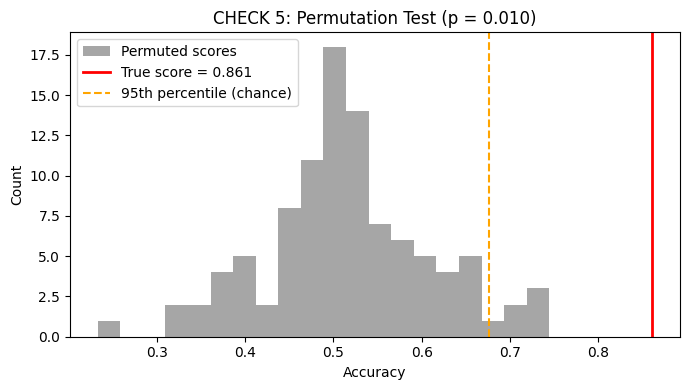

CHECK 5: Permutation Test
  True accuracy      : 0.8611
  Chance level (mean): 0.5159
  p-value            : 0.0099
  VERDICT: ✓✓ p < 0.01 — highly significant, not random


In [ ]:
# ── CHECK 5: Permutation Test ──────────────────────────────────────────────
# Question: is the accuracy statistically better than chance (random labels)?
# p < 0.05 → result is real. p > 0.10 → could be random. MOST IMPORTANT for small N.
# n_permutations=100 takes ~2-5 min. Reduce to 50 for a quick first check.

result3 = check3_permutation_test(X_v, y_v, best_params_v, n_permutations=100)

In [ ]:
# ── SUMMARY ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("VERIFICATION SUMMARY")
print("="*60)
print(f"Task: {VERIFY_TASK}  |  SR: {VERIFY_SR}")
print()

if 'result1' in dir():
    print(f"Check 1 — Optimism bias   : {result1['bias']:+.4f}  (nested={result1['nested']:.4f})")
if 'result2' in dir():
    print(f"Check 2 — Learning slope  : {result2['test_mean'][-1] - result2['test_mean'][0]:+.4f}")
if 'result3' in dir():
    print(f"Check 3 — p-value         : {result3['p_value']:.4f}  (score={result3['true_score']:.4f})")


VERIFICATION SUMMARY
Task: H_vs_PC  |  SR: SR_1005_preprocessed

Check 1 — Train/Test gap  : -0.1714
Check 2 — Optimism bias   : +0.1611  (nested=0.7444)
Check 3 — Max fold std    : 0.1832
Check 4 — Learning slope  : +0.4250
Check 5 — p-value         : 0.0099  (score=0.8611)


### Table 1 — Maiti 2021 Format
Replicates Table 1 (columns 7-9): supervised k-fold results per SR.
Format per cell: `accuracy/sensitivity/specificity/SD`

In [ ]:
# ── Table 1 — Maiti 2021 format, both whole_sr and PCA ───────────────────
# Paper columns 7-9:
#   Col 7: 9-fold  | H vs PCa
#   Col 8: 9-fold  | H vs PCa+BC+KC  (task = H_vs_KC_BC_PC)
#   Col 9: 7-fold  | H vs BC+KC
# Each cell: acc/sens/spec/SD
# Two sub-rows per SR: whole_sr and PCA top 4

SR_ORDER = [1005, 1190, 1203, 530, 1050, 2170, 1130, 1170]

def fmt(acc, sens, spec, std):
    std_str = f'{std:.2f}' if std is not None and not pd.isna(std) else '--'
    return f'{acc:.2f}/{sens:.2f}/{spec:.2f}/{std_str}'

def lookup(sr_center, task, method, pca_flag):
    mask = (
        (results_df['sr_type'] == 'single') &
        (results_df['pca'] == pca_flag) &
        (results_df['sr_used'] == f'SR_{sr_center}') &
        (results_df['task'] == task) &
        (results_df['method'] == method)
    )
    r = results_df[mask]
    if r.empty:
        return 'N/A'
    row = r.iloc[0]
    return fmt(row['accuracy'], row['sensitivity'], row['specificity'], row['accuracy_std'])

rows = []
for sr in SR_ORDER:
    for pca_flag, feat_label in [(0, 'whole_sr'), (1, 'PCA top4')]:
        rows.append({
            'SR (cm⁻¹)':             sr,
            'Features':              feat_label,
            'H vs PCa\n(9-fold)':    lookup(sr, 'H_vs_PC',       '9-fold (x10)', pca_flag),
            'H vs PCa+BC+KC\n(9-fold)': lookup(sr, 'H_vs_KC_BC_PC', '9-fold (x10)', pca_flag),
            # 'H vs BC+KC\n(7-fold)':  lookup(sr, 'H_vs_KC_BC',    '7-fold (x10)', pca_flag),
        })

table1 = pd.DataFrame(rows)
table1.to_csv('eval_result_data/table1_results.csv', index=False)
print("Table 1 — acc/sens/spec/SD per SR and feature type")
print("Saved: eval_result_data/table1_results.csv")
print()
table1

Table 1 — acc/sens/spec/SD per SR and feature type
Saved: eval_result_data/table1_results.csv



,SR (cm⁻¹),Features,H vs PCa\n(9-fold),H vs PCa+BC+KC\n(9-fold)
0,1005,whole_sr,0.88/0.92/0.85/0.01,0.71/0.80/0.93/0.03
1,1005,PCA top4,0.95/0.86/1.00/0.01,0.67/0.70/0.97/0.02
2,1190,whole_sr,0.68/0.72/0.66/0.06,0.49/0.81/0.63/0.03
3,1190,PCA top4,0.77/0.66/0.83/0.03,0.56/0.76/0.71/0.04
4,1203,whole_sr,0.65/0.97/0.44/0.02,0.49/1.00/0.42/0.02
5,1203,PCA top4,0.79/0.82/0.77/0.03,0.55/0.76/0.74/0.03
6,530,whole_sr,0.74/0.70/0.76/0.02,0.61/0.72/0.76/0.02
7,530,PCA top4,0.73/0.77/0.70/0.04,0.49/1.00/0.42/0.02
8,1050,whole_sr,0.82/0.78/0.85/0.02,0.63/0.82/0.82/0.03
9,1050,PCA top4,0.82/0.86/0.80/0.03,0.61/0.83/0.68/0.02


In [ ]:
# ── Pivot for easier reading — accuracy only ───────────────────────────────
# Shows raw accuracy numbers in a compact grid: rows=SR, cols=task+feature

def get_acc(sr_center, task, method, pca_flag):
    mask = (
        (results_df['sr_type'] == 'single') &
        (results_df['pca'] == pca_flag) &
        (results_df['sr_used'] == f'SR_{sr_center}') &
        (results_df['task'] == task) &
        (results_df['method'] == method)
    )
    r = results_df[mask]
    return round(r['accuracy'].values[0], 3) if not r.empty else None

acc_rows = []
for sr in SR_ORDER:
    acc_rows.append({
        'SR':                      sr,
        'H_vs_PC whole':           get_acc(sr, 'H_vs_PC',       '9-fold (x10)', 0),
        'H_vs_PC PCA':             get_acc(sr, 'H_vs_PC',       '9-fold (x10)', 1),
        'H_vs_KC_BC_PC whole':     get_acc(sr, 'H_vs_KC_BC_PC', '9-fold (x10)', 0),
        'H_vs_KC_BC_PC PCA':       get_acc(sr, 'H_vs_KC_BC_PC', '9-fold (x10)', 1),
        # 'H_vs_KC_BC whole':        get_acc(sr, 'H_vs_KC_BC',    '7-fold (x10)', 0),
        # 'H_vs_KC_BC PCA':          get_acc(sr, 'H_vs_KC_BC',    '7-fold (x10)', 1),
    })

acc_table = pd.DataFrame(acc_rows).set_index('SR')
acc_table
# acc_table.style.highlight_max(axis=0, color='lightgreen')

,H_vs_PC whole,H_vs_PC PCA,H_vs_KC_BC_PC whole,H_vs_KC_BC_PC PCA
SR,,,,
1005,0.879,0.947,0.714,0.671
1190,0.681,0.765,0.486,0.563
1203,0.651,0.788,0.486,0.547
530,0.737,0.730,0.606,0.488
1050,0.821,0.823,0.631,0.606
2170,0.844,0.677,0.622,0.390
1130,0.672,0.681,0.524,0.496
1170,0.626,0.802,0.573,0.573


                                                                                                                                                                                                         
Likely sources of   discrepancy:                                                                                                                                                                                 
                                                                                                                                                                                                                                                                   
                                                                                                                                                                                                                 
  1. Normalization scope                                                                                                                                                                                       
  Paper: "mean-centred and normalized by dividing through their standard deviation" — ambiguous whether this is per-SR or global. You do per-SR. If the paper normalizes globally, the relative differences      
  between SRs are preserved, which helps the SVM.                                                                                                                                                                
                                                                                                                                                                                                               
  2. class_weight='balanced'                                                                                                                                                                                     
  Paper doesn't mention this. With imbalanced classes (26H vs 17PC vs 3KC vs 5BC), not using balanced weights would bias toward majority class and artificially inflate accuracy while hurting sensitivity.    
                                                                                                                                                                                                                 
  3. Sigma optimization                                                                                                                                                                                        
  Paper optimizes sigma per-SR until accuracy is maximised — essentially a nested search. Your grid search does this too, but with a discrete grid. The paper may use finer-grained sigma search.                
                                                                                                                                                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                 
                            
                                                     

## Thesis Plots — Plots 4–7 (require raw data)
Run after the data loading and SR preprocessing cells.

In [ ]:
import importlib, plot_results
importlib.reload(plot_results)
from plot_results import (plot_learning_curve, plot_permutation_test,
                          plot_loocv_categorisation, plot_pca_scatter)

# Build X and y for SR 1005, H vs PC
mask_pc = np.isin(df_new['infoP'], ['H', 'PC'])
df_pc   = df_new[mask_pc].reset_index(drop=True)
y_pc    = df_pc['infoP'].values
X_1005  = np.array(list(df_pc['SR_1005_preprocessed']))

print(f'X shape: {X_1005.shape}, classes: {dict(zip(*np.unique(y_pc, return_counts=True)))}')

X shape: (43, 124), classes: {'H': np.int64(26), 'PC': np.int64(17)}


Saved: eval_result_data/plots/plot4_learning_curve.png


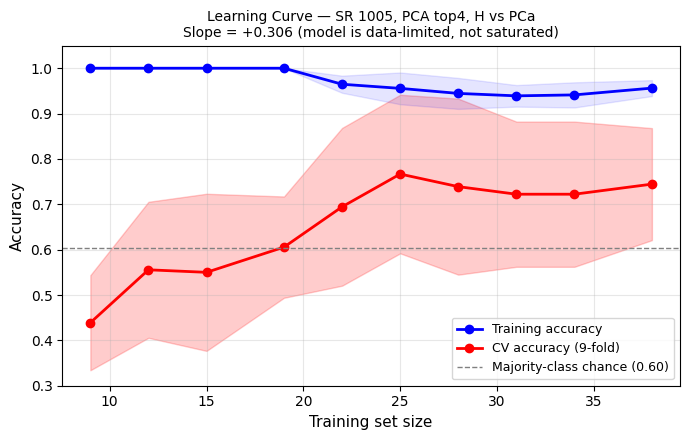

In [ ]:
# Plot 4: Learning curve
plot_learning_curve(X_1005, y_pc)

Running 500 permutations...
Saved: eval_result_data/plots/plot5_permutation_test.png


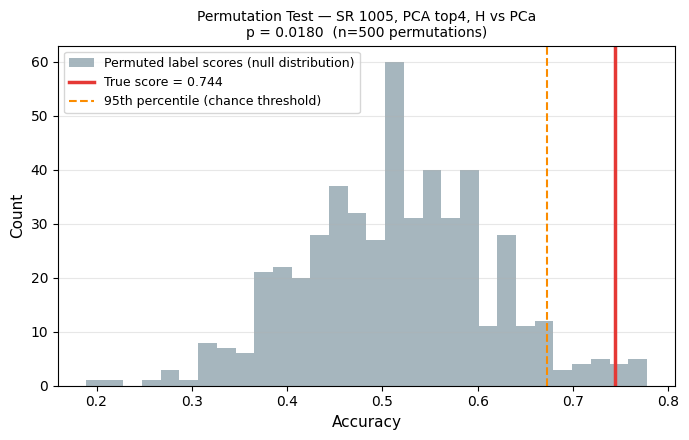

np.float64(0.017964071856287425)

In [ ]:
# Plot 5: Permutation test (500 permutations — takes ~2 min)
plot_permutation_test(X_1005, y_pc, n_permutations=500)

Saved: eval_result_data/plots/plot6_loocv_categorisation.png


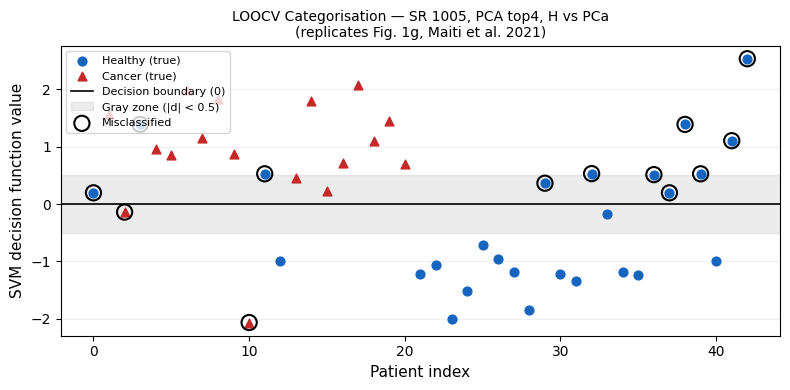

In [ ]:
# Plot 6: LOOCV categorisation (replicates Fig 1g)
# Re-run LOOCV to get decision scores
from SVM_implement import SVMBreathClassifier
clf = SVMBreathClassifier()
params_1005 = {
    'sigma': 0, 'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale',
    'degree': None, 'feature_type': 'pca', 'n_pca_components': 4
}
r = clf.loocv_validation(X_1005, y_pc, params_1005)
plot_loocv_categorisation(y_pc, r['decisions'])

Saved: eval_result_data/plots/plot7_pca_scatter.png


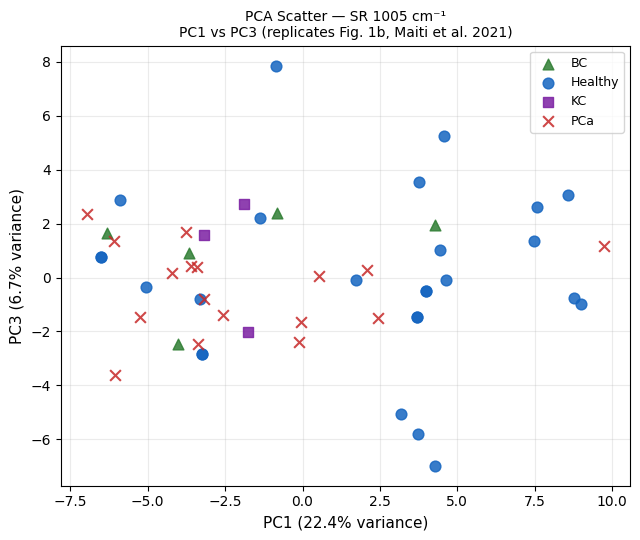

In [ ]:
# Plot 7: PCA scatter PC1 vs PC3 (replicates Fig 1b)
# Use all patients for this plot (H, PC, KC, BC)
X_1005_all = np.array(list(df_new['SR_1005_preprocessed']))
y_all      = df_new['infoP'].values
plot_pca_scatter(X_1005_all, y_all)